In [18]:
import os
import glob
import random
import cv2
import PIL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from PIL import Image

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# --------------------------
# Seeds for reproducibility
# --------------------------
random.seed(100)
np.random.seed(42)
tf.random.set_seed(42)

In [19]:
# --------------------------
# 1) Read DICOM metadata CSV (CBIS-DDSM)
# --------------------------
print("--- Loading DICOM metadata CSV ---")
dicom_csv_path = '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv'
image_dir = '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg'

try:
    dicom_data = pd.read_csv(dicom_csv_path)
    print("✅ Cell 2: Successfully loaded 'dicom_info.csv'!")
    print("Here are the first 5 rows of the data:")
    
    # display() is a notebook-friendly way to show a dataframe
    display(dicom_data.head()) 
    
except FileNotFoundError:
    print(f"❌ Error: Could not find file at {dicom_csv_path}")
    print("Please check the dataset path in Kaggle.")

# Also ignore harmless warnings
import warnings
warnings.simplefilter(action='ignore', category=RuntimeWarning)

--- Loading DICOM metadata CSV ---
✅ Cell 2: Successfully loaded 'dicom_info.csv'!
Here are the first 5 rows of the data:


,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [23]:
# --------------------------
# Exploring the data frame
# --------------------------
print("--- Displaying top 5 rows (again) ---")
# This command is just to explore the data in the notebook
dicom_data.head()

print("✅ Cell 3: Dataframe displayed.")

--- Displaying top 5 rows (again) ---
✅ Cell 3: Dataframe displayed.


--- Sorting Image Paths ---
🖼️ Found 3567 'Cropped Images' paths.
🖼️ Found 2857 'Full Mammogram' paths.
🖼️ Found 3247 'ROI Mask' paths.

Displaying 3 example(s) of: Cropped Image


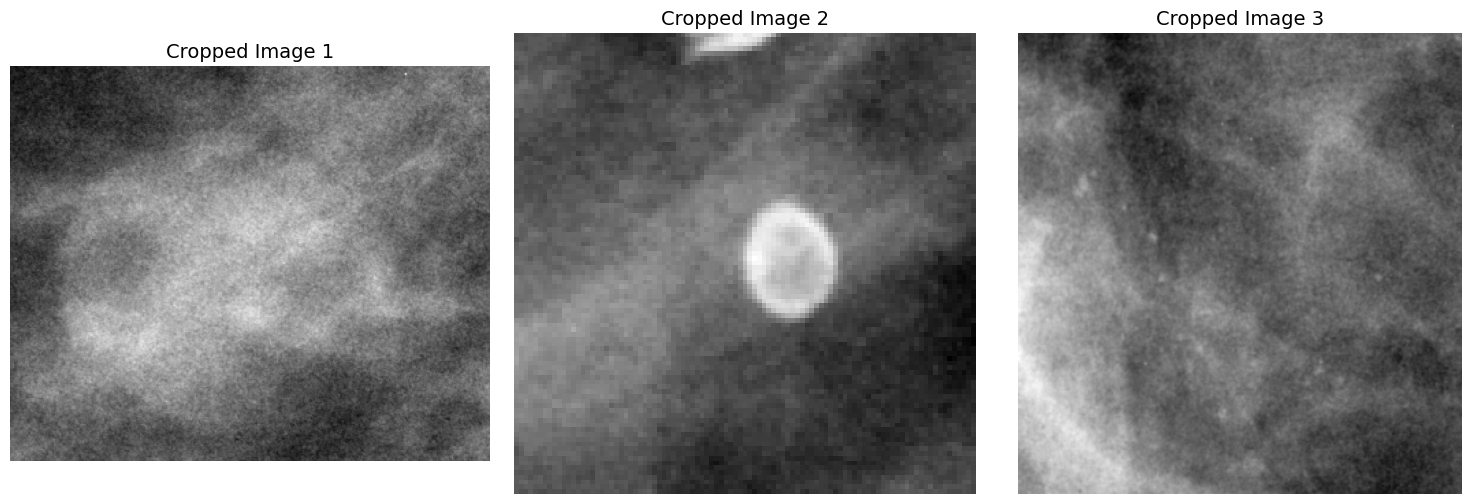


Displaying 3 example(s) of: Full Mammogram Image


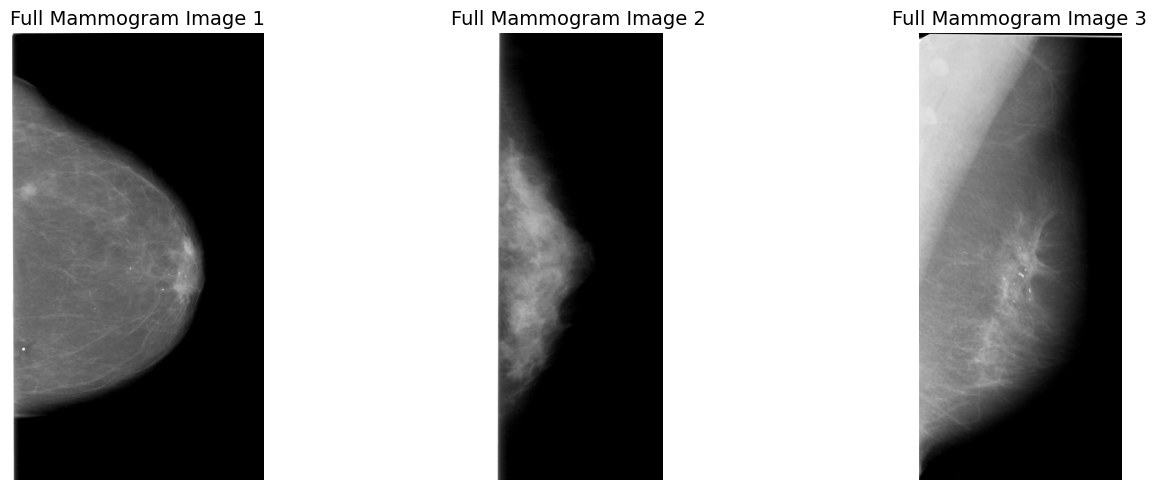


Displaying 3 example(s) of: ROI Mask


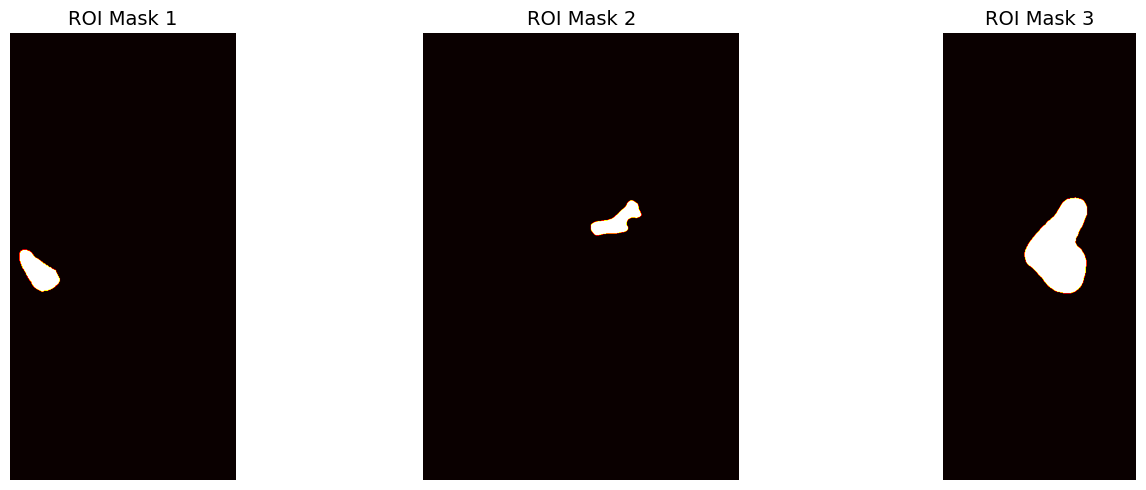


✅ Cell 4: Successfully sorted paths and displayed sample images.


In [24]:
# --------------------------
# 2) Inspect and prepare lists for cropped / full / ROI images
# --------------------------
from PIL import Image
import matplotlib.pyplot as plt

print("--- Sorting Image Paths ---")

# Go through the 'dicom_data' dataframe and find all rows for 'cropped images'
cropped_images = dicom_data[dicom_data.SeriesDescription == 'cropped images'].image_path
# Fix the file paths so the computer can find them
cropped_images = cropped_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
print(f"🖼️ Found {len(cropped_images)} 'Cropped Images' paths.")

# Find all rows for 'full mammogram images'
full_mammogram_images = dicom_data[dicom_data.SeriesDescription == 'full mammogram images'].image_path
full_mammogram_images = full_mammogram_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
print(f"🖼️ Found {len(full_mammogram_images)} 'Full Mammogram' paths.")

# Find all rows for 'ROI mask images'
ROI_mask_images = dicom_data[dicom_data.SeriesDescription == 'ROI mask images'].image_path
ROI_mask_images = ROI_mask_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
print(f"🖼️ Found {len(ROI_mask_images)} 'ROI Mask' paths.")


# --- Displaying Sample Images ---

# Function to display a list of images
def display_images(image_paths, title, num_images=1, cmap='gray'):
    print(f"\nDisplaying {num_images} example(s) of: {title}")
    
    # Check if we have any images to show
    if len(image_paths) == 0:
        print(f"❌ No images found for {title}.")
        return

    # Create a subplot grid
    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 5, 5))
    
    # Handle case for single image (axes is not an array)
    if num_images == 1:
        axes = [axes]
        
    for i, ax in enumerate(axes):
        if i < len(image_paths):
            try:
                # Open and display the image
                img = Image.open(image_paths.iloc[i]).convert("L")  # Convert to grayscale
                ax.imshow(img, cmap=cmap)
                ax.set_title(f"{title} {i+1}", fontsize=14)
                ax.axis('off')
            except FileNotFoundError:
                ax.set_title(f"Image not found!", color='red')
                ax.axis('off')
        else:
            ax.axis('off') # Hide unused subplots
            
    plt.tight_layout()
    plt.show()

# Display first 3 cropped images
display_images(cropped_images, "Cropped Image", num_images=3)

# Display first 3 full mammogram images
display_images(full_mammogram_images, "Full Mammogram Image", num_images=3)

# Display first 3 ROI mask images (using 'hot' colormap to see the mask better)
display_images(ROI_mask_images, "ROI Mask", num_images=3, cmap='hot')

print("\n✅ Cell 4: Successfully sorted paths and displayed sample images.")

In [26]:
# --------------------------
# 3) Load and clean calc/mass description CSVs
# --------------------------
import plotly.express as px

print("--- Loading Case Description CSVs (Labels) ---")

try:
    # --- Load the datasets ---
    calc_case_df = pd.read_csv('/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv')
    mass_case_df = pd.read_csv('/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv')
    print("✅ Successfully loaded 'calc_case_description' and 'mass_case_description' CSVs.")

    # --- Clean Calc Dataframe ---
    print("\n--- Cleaning Calcification Data (Data_cleaning_1) ---")
    Data_cleaning_1 = calc_case_df.copy()
    # Rename columns to be more programming-friendly (e.g., no spaces)
    Data_cleaning_1 = Data_cleaning_1.rename(columns={
        'calc type':'calc_type', 'calc distribution':'calc_distribution',
        'image view':'image_view', 'left or right breast':'left_or_right_breast',
        'breast density':'breast_density', 'abnormality type':'abnormality_type'
    })
    
    # Backfill missing values (this assumes missing values are similar to the row below)
    Data_cleaning_1['calc_type'] = Data_cleaning_1['calc_type'].bfill()
    Data_cleaning_1['calc_distribution'] = Data_cleaning_1['calc_distribution'].bfill()
    print("Renamed columns and filled missing values for calc data.")

    # --- Clean Mass Dataframe ---
    print("\n--- Cleaning Mass Data (Data_cleaning_2) ---")
    Data_cleaning_2 = mass_case_df.copy()
    # Rename columns
    Data_cleaning_2 = Data_cleaning_2.rename(columns={
        'mass shape':'mass_shape', 'left or right breast':'left_or_right_breast',
        'mass margins':'mass_margins', 'image view':'image_view', 'abnormality type':'abnormality_type'
    })
    
    # Backfill missing values
    Data_cleaning_2['mass_shape'] = Data_cleaning_2['mass_shape'].bfill()
    Data_cleaning_2['mass_margins'] = Data_cleaning_2['mass_margins'].bfill()
    print("Renamed columns and filled missing values for mass data.")
    
    
    # --- Visualize the Labels (Pathology) ---
    print("\n--- Visualizing the distribution of labels ---")
    
    # Combine the 'pathology' column from both dataframes to see the total counts
    total_pathology = pd.concat([Data_cleaning_1['pathology'], Data_cleaning_2['pathology']])
    
    # Create a Pie Chart
    pathology_counts = total_pathology.value_counts().reset_index()
    pathology_counts.columns = ['pathology', 'count']

    fig = px.pie(pathology_counts, 
                 values='count', 
                 names='pathology', 
                 title='Distribution of All Labels (Benign vs. Malignant)',
                 color_discrete_map={'MALIGNANT':'#FF6347', 'BENIGN':'#90EE90', 'BENIGN_WITHOUT_CALLBACK':'#ADD8E6'})
    
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.show()
    
    print("\n✅ Cell 5: Successfully cleaned and visualized the label data.")

except FileNotFoundError:
    print("❌ Error: Could not find the calc_case or mass_case CSV files.")
    print("Please check the dataset path.")
except Exception as e:
    print(f"An error occurred: {e}")

--- Loading Case Description CSVs (Labels) ---
✅ Successfully loaded 'calc_case_description' and 'mass_case_description' CSVs.

--- Cleaning Calcification Data (Data_cleaning_1) ---
Renamed columns and filled missing values for calc data.

--- Cleaning Mass Data (Data_cleaning_2) ---
Renamed columns and filled missing values for mass data.

--- Visualizing the distribution of labels ---



✅ Cell 5: Successfully cleaned and visualized the label data.


In [27]:
# --------------------------
# 4) Visualization helpers 
# --------------------------
import plotly.express as px

print("--- Visualizing Image Type Counts ---")

# Count how many times each value appears in the 'SeriesDescription' column
r = dicom_data['SeriesDescription'].value_counts().reset_index()

# Rename the columns for clarity in the plot
r.columns = ['SeriesDescription', 'Count']

# Create an interactive bar chart
fig = px.bar(r, 
             x='SeriesDescription', 
             y='Count', 
             title='Types of Images in the Dataset',
             color='SeriesDescription', # Give each bar a different color
             text='Count') # Show the count value on top of the bar

fig.update_layout(xaxis_title="Image Type", yaxis_title="Total Count")
fig.show()

print("\n✅ Cell 6: Successfully displayed the bar chart.")

--- Visualizing Image Type Counts ---



✅ Cell 6: Successfully displayed the bar chart.


In [30]:
# -----------------------------------------------------------------
# 5) --- DATASET FOR MODELING (FIXED CELL 7, v3) ---
# Fixing the merge error by EXTRACTING the patient ID
# -----------------------------------------------------------------
import os
import random
import pandas as pd
import plotly.express as px

print("--- 🩺 Building the Mammogram Dataset for Modeling (Fixing Merge) ---")

# 1. Define the base directories
image_dir = '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg'
csv_dir = '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv'

# 2. Load ALL FOUR description CSVs
print("Loading all 4 label CSVs (calc/mass, train/test)...")
try:
    calc_train_df = pd.read_csv(os.path.join(csv_dir, 'calc_case_description_train_set.csv'))
    mass_train_df = pd.read_csv(os.path.join(csv_dir, 'mass_case_description_train_set.csv'))
    calc_test_df = pd.read_csv(os.path.join(csv_dir, 'calc_case_description_test_set.csv'))
    mass_test_df = pd.read_csv(os.path.join(csv_dir, 'mass_case_description_test_set.csv'))
except FileNotFoundError as e:
    print(f"❌ Error loading CSVs: {e}\nPlease check the dataset path. Stopping.")
    raise e

# 3. Combine them to get a PatientID-to-Label mapping
all_labels_df = pd.concat([calc_train_df, mass_train_df, calc_test_df, mass_test_df], ignore_index=True)
all_labels_df = all_labels_df[['patient_id', 'pathology']]
# Clean the 'patient_id' column by removing any hidden spaces
all_labels_df['patient_id'] = all_labels_df['patient_id'].str.strip()
all_labels_df = all_labels_df.drop_duplicates(subset=['patient_id']).dropna()
print(f"✅ Found {len(all_labels_df)} unique patient-pathology labels.")


# 4. Load the main 'dicom_info.csv' to get all file paths
try:
    if 'dicom_data' not in locals():
         print("Re-loading dicom_info.csv...")
         dicom_csv_path = os.path.join(csv_dir, 'dicom_info.csv')
         dicom_data = pd.read_csv(dicom_csv_path)
         
    # 5. Filter dicom_data to get ONLY the cropped images
    cropped_df = dicom_data[dicom_data.SeriesDescription == 'cropped images'].copy()

    # --- THIS IS THE FIX ---
    # Extract the 'P_XXXXX' pattern from the long PatientID string
    # This creates a new column with just the simple ID
    print("Extracting simple patient IDs (e.g., 'P_00001') from 'dicom_info'...")
    cropped_df['extracted_patient_id'] = cropped_df['PatientID'].str.extract(r'(P_\d{5})')
    # -----------------------

    print(f"🖼️ Found {len(cropped_df)} total 'cropped image' paths in dicom_info.csv")

    # --- DEBUGGING: Let's look at the *new* keys before merging ---
    print("\n--- DEBUGGING INFO ---")
    print("Example 'patient_id' from labels CSVs:\n", all_labels_df['patient_id'].head(3))
    print("\nExample 'extracted_patient_id' from dicom_info CSV:\n", cropped_df['extracted_patient_id'].head(3))
    print("------------------------\n")
    
    # 6. Merge the cropped image paths with the patient labels
    final_data_df = cropped_df.merge(
        all_labels_df,
        left_on='extracted_patient_id',  # <-- Use the new extracted ID
        right_on='patient_id',          # <-- Use the simple ID
        how='left'             
    )
    
    # 7. Clean the merged data
    final_data_df = final_data_df.dropna(subset=['image_path', 'pathology'])
    print(f"✅ Merged paths and labels. Found {len(final_data_df)} cropped images with a matching pathology label.")

except Exception as e:
    print(f"❌ Error: Could not load or process 'dicom_info.csv'. Please re-run Cell 2 first.")
    print(f"Details: {e}")
    raise

# 8. Create the full, correct file paths
def fix_dicom_path(dicom_path):
    try:
        full_path = dicom_path.replace('CBIS-DDSM/jpeg', image_dir)
        return full_path
    except:
        return None

final_data_df['full_path'] = final_data_df['image_path'].apply(fix_dicom_path)
print("Created full file paths for all images.")

# 9. Sort the *valid* file paths into cancer/non-cancer lists
non_cancer_imgs = []
cancer_imgs = []

print("Verifying all file paths actually exist (this may take a moment)...")
for index, row in final_data_df.iterrows():
    pathology = row['pathology']
    full_path = row['full_path']
    
    if full_path and os.path.exists(full_path):
        if pathology == 'MALIGNANT':
            cancer_imgs.append(full_path)
        elif pathology == 'BENIGN' or pathology == 'BENIGN_WITHOUT_CALLBACK':
            non_cancer_imgs.append(full_path)

print(f"\n--- ✅ Verification Complete ---")
print(f"Total valid Non-Cancer (Benign) paths found: {len(non_cancer_imgs)}")
print(f"Total valid Cancer (Malignant) paths found: {len(cancer_imgs)}")

# 10. Balance the dataset by sampling
min_class_size = min(len(non_cancer_imgs), len(cancer_imgs))

if min_class_size > 0:
    print(f"\nBalancing dataset by sampling {min_class_size} images from each class.")
    non_cancer_imgs = random.sample(non_cancer_imgs, min_class_size)
    cancer_imgs = random.sample(cancer_imgs, min_class_size)
    
    # --- Visualize the Final Dataset Distribution ---
    final_counts = pd.DataFrame({
        'Label': ['Non-Cancer (Benign)', 'Cancer (Malignant)'],
        'Count': [len(non_cancer_imgs), len(cancer_imgs)]
    })
    
    fig = px.bar(final_counts, 
                 x='Label', y='Count', 
                 title='Final Balanced Dataset for Training',
                 color='Label', 
                 text='Count',
                 color_discrete_map={'Non-Cancer (Benign)':'#90EE90', 'Cancer (Malignant)':'#FF6347'})
    fig.show()
    
    print(f"\n✅ Cell 7: Successfully created a balanced dataset with {min_class_size} images per class.")
else:
    print("\n❌ Error: One or both classes have 0 valid images found.")
    print("This means the merge operation failed or the file paths are still not correct.")
    print("Please check the debug output and dataset structure.")

# --- END OF REPLACEMENT FOR CELL 7 ---

--- 🩺 Building the Mammogram Dataset for Modeling (Fixing Merge) ---
Loading all 4 label CSVs (calc/mass, train/test)...
✅ Found 1566 unique patient-pathology labels.
Extracting simple patient IDs (e.g., 'P_00001') from 'dicom_info'...
🖼️ Found 3567 total 'cropped image' paths in dicom_info.csv

--- DEBUGGING INFO ---
Example 'patient_id' from labels CSVs:
 0    P_00005
2    P_00007
4    P_00008
Name: patient_id, dtype: object

Example 'extracted_patient_id' from dicom_info CSV:
 0    P_01265
3    P_00562
6    P_00181
Name: extracted_patient_id, dtype: object
------------------------

✅ Merged paths and labels. Found 3567 cropped images with a matching pathology label.
Created full file paths for all images.
Verifying all file paths actually exist (this may take a moment)...

--- ✅ Verification Complete ---
Total valid Non-Cancer (Benign) paths found: 2093
Total valid Cancer (Malignant) paths found: 1474

Balancing dataset by sampling 1474 images from each class.



✅ Cell 7: Successfully created a balanced dataset with 1474 images per class.



--- ⏳ Loading 1474 Non-Cancer (Benign) images... ---


Loading Non-Cancer: 100%|██████████| 1474/1474 [00:28<00:00, 50.85img/s]



--- ⏳ Loading 1474 Cancer (Malignant) images... ---


Loading Cancer: 100%|██████████| 1474/1474 [00:39<00:00, 37.48img/s]



Combining and shuffling the dataset...
✅ Done.

Successfully loaded 2948 total images.
Final X shape (images): (2948, 50, 50, 3)
Final y shape (labels): (2948,)

--- Displaying one random example of each class ---


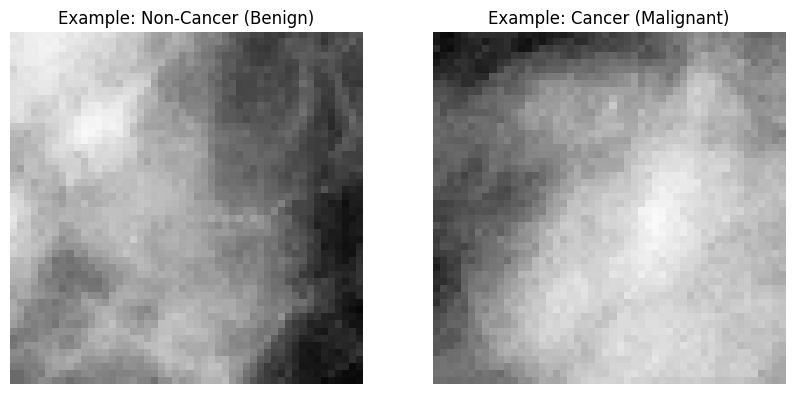


✅ Cell 8: Successfully loaded, processed, and verified the image data.


In [31]:
# -----------------------------------------------------------------
# 6) --- Build arrays: read files, resize, convert GRY->RGB (CELL 8) ---
# -----------------------------------------------------------------
from tqdm import tqdm  # For a nice progress bar
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_and_resize_mammogram(path, size=(50,50)):
    """
    Reads a grayscale mammogram, resizes it,
    and converts it to a 3-channel image to match the CNN input.
    """
    try:
        # Read the image in grayscale mode
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE) 
        if img is None:
            return None
        
        # Convert the 1-channel grayscale to 3-channel
        # (This just duplicates the gray channel 3 times)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        
        # Resize to the (50, 50) size your model expects
        img = cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)
        return img
    except Exception as e:
        # print(f"Error reading or processing {path}: {e}") # Uncomment to debug
        return None

# --- Now, loop through our 'non_cancer_imgs' and 'cancer_imgs' lists from Cell 7 ---

non_img_arr = []
can_img_arr = []

print(f"\n--- ⏳ Loading {len(non_cancer_imgs)} Non-Cancer (Benign) images... ---")
# Use tqdm for a nice progress bar
for img_path in tqdm(non_cancer_imgs, desc="Loading Non-Cancer", unit="img"):
    img = read_and_resize_mammogram(img_path, (50,50))
    if img is not None:
        non_img_arr.append([img, 0]) # 0 for Non-Cancer (Benign)

print(f"\n--- ⏳ Loading {len(cancer_imgs)} Cancer (Malignant) images... ---")
for img_path in tqdm(cancer_imgs, desc="Loading Cancer", unit="img"):
    img = read_and_resize_mammogram(img_path, (50,50))
    if img is not None:
        can_img_arr.append([img, 1]) # 1 for Cancer (Malignant)

# --- Combine, shuffle, and convert to final arrays ---
print("\nCombining and shuffling the dataset...")
breast_img_arr = non_img_arr + can_img_arr
random.shuffle(breast_img_arr)

# Create the final X and y arrays
X = np.array([i[0] for i in breast_img_arr], dtype=np.float32)
y = np.array([i[1] for i in breast_img_arr], dtype=np.int32)

print('✅ Done.')

# --- Show visualization of what we loaded ---
if len(X) > 0:
    print(f"\nSuccessfully loaded {len(X)} total images.")
    print('Final X shape (images):', X.shape)
    print('Final y shape (labels):', y.shape)

    print("\n--- Displaying one random example of each class ---")
    
    # Show one example of each class that we loaded
    plt.figure(figsize=(10, 5))
    
    try:
        # Show first non-cancer (0) image
        plt.subplot(1, 2, 1)
        # Find first 0 in y and convert pixel data to 'uint8' for display
        plt.imshow(X[np.where(y == 0)[0][0]].astype('uint8')) 
        plt.title("Example: Non-Cancer (Benign)")
        plt.axis('off')

        # Show first cancer (1) image
        plt.subplot(1, 2, 2)
        # Find first 1 in y and convert pixel data to 'uint8' for display
        plt.imshow(X[np.where(y == 1)[0][0]].astype('uint8')) 
        plt.title("Example: Cancer (Malignant)")
        plt.axis('off')
        
        plt.show()
    except IndexError:
        print("Could not find an example for each class to display.")
    
    print("\n✅ Cell 8: Successfully loaded, processed, and verified the image data.")
else:
    print("\n❌ Error: The 'X' array is empty. No images were loaded.")
    print("This likely means the 'read_and_resize_mammogram' function failed.")

In [32]:
# --------------------------
# 7) Preprocess (normalize) (CELL 9)
# --------------------------
import numpy as np

print(f"--- Normalize Pixel Data ---")

# Check if X is not empty
if 'X' in locals() and X.size > 0:
    
    # Print the original range of pixel values
    print(f"Original pixel value range: {np.min(X)} to {np.max(X)}")
    
    # Normalize the data by dividing by 255
    X = X / 255.0
    
    # Print the new range
    print(f"New normalized pixel value range: {np.min(X)} to {np.max(X)}")
    print("\n✅ Cell 9: Successfully normalized image data to [0, 1] range.")
    
else:
    print("❌ Error: 'X' array is empty or not defined. Please re-run Cell 8.")

--- Normalize Pixel Data ---
Original pixel value range: 0.0 to 255.0
New normalized pixel value range: 0.0 to 1.0

✅ Cell 9: Successfully normalized image data to [0, 1] range.


In [33]:
# -----------------------------------------------------------------
# 8) Train-test split and label encoding (CELL 10)
# -----------------------------------------------------------------
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import plotly.graph_objects as go

print("---  splitting Dataset into Training and Testing Sets ---")

# Check if X and y exist
if 'X' not in locals() or 'y' not in locals():
    print("❌ Error: 'X' or 'y' arrays not found. Please re-run Cell 8.")
else:
    # Split the data: 80% for training, 20% for testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                        test_size=0.20, 
                                                        random_state=42,
                                                        stratify=y) # Stratify ensures the split has the same % of classes

    print(f"Total images: {len(X)}")
    print(f"Training images (X_train): {len(X_train)}")
    print(f"Testing images (X_test):  {len(X_test)}")

    # --- Convert labels to one-hot encoding ---
    print("\n--- Converting labels to one-hot format ---")
    
    # Save a copy of the original 0/1 test labels for the confusion matrix later
    y_test_original = y_test.copy() 
    
    y_train = to_categorical(y_train, 2)
    y_test = to_categorical(y_test, 2)

    print("Original y_train label '0' is now:", y_train[0])
    print("Original y_train label '1' is now:", y_train[np.where(y_train[:,1] == 1)[0][0]]) # Find first '1'

    # --- Visualize the Split ---
    fig = go.Figure(data=[
        go.Bar(name='Train', x=['Benign', 'Malignant'], y=np.sum(y_train, axis=0), text=np.sum(y_train, axis=0), textposition='auto', marker_color='#90EE90'),
        go.Bar(name='Test', x=['Benign', 'Malignant'], y=np.sum(y_test, axis=0), text=np.sum(y_test, axis=0), textposition='auto', marker_color='#FF6347')
    ])
    fig.update_layout(
        title='Data Split: Training vs. Testing Sets',
        xaxis_title='Class',
        yaxis_title='Number of Images',
        barmode='group'
    )
    fig.show()
    
    print("\n✅ Cell 10: Successfully split data and one-hot encoded labels.")
    print("\nFinal Data Shapes for Training:")
    print('X_train shape (images):', X_train.shape)
    print('y_train shape (labels):', y_train.shape)
    print('\nFinal Data Shapes for Testing:')
    print('X_test shape (images): ', X_test.shape)
    print('y_test shape (labels): ', y_test.shape)

---  splitting Dataset into Training and Testing Sets ---
Total images: 2948
Training images (X_train): 2358
Testing images (X_test):  590

--- Converting labels to one-hot format ---
Original y_train label '0' is now: [1. 0.]
Original y_train label '1' is now: [0. 1.]



✅ Cell 10: Successfully split data and one-hot encoded labels.

Final Data Shapes for Training:
X_train shape (images): (2358, 50, 50, 3)
y_train shape (labels): (2358, 2)

Final Data Shapes for Testing:
X_test shape (images):  (590, 50, 50, 3)
y_test shape (labels):  (590, 2)


--- 🎨 Defining the Data Augmentation Rules ---
✅ Augmentation generator created with the following rules:
 - Rotation: 20 degrees
 - Width/Height Shift: 10%
 - Zoom: 10%
 - Horizontal Flip: True

--- 🖼️ Visualizing a sample augmented image 9 times ---


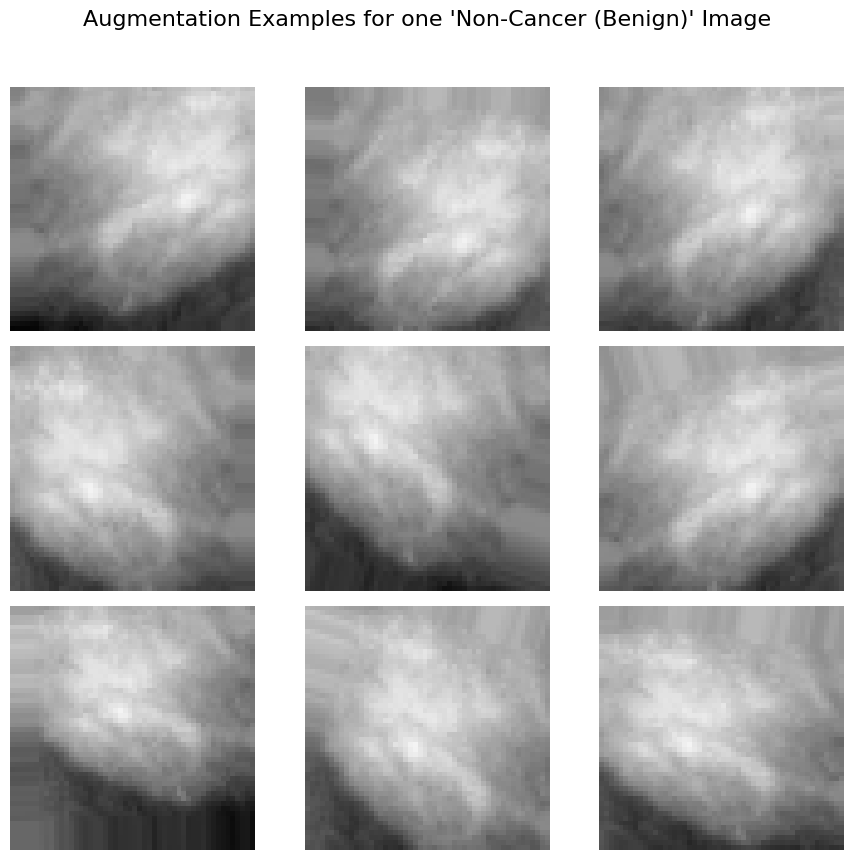


✅ Cell 11: Data augmentation generator is defined and visualized.


In [37]:
# -----------------------------------------------------------------
# 9) Data augmentation (FIXED CELL 11)
# -----------------------------------------------------------------
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np # Make sure numpy is imported

# --- THIS IS THE FIX ---
# Define the class labels dictionary
class_labels = {0: 'Non-Cancer (Benign)', 1: 'Cancer (Malignant)'}
# -----------------------

print("--- 🎨 Defining the Data Augmentation Rules ---")

# We create an ImageDataGenerator instance with a set of rules
datagen = ImageDataGenerator(
    rotation_range=20,      # Randomly rotate images up to 20 degrees
    width_shift_range=0.1,  # Randomly shift images horizontally (10% of width)
    height_shift_range=0.1, # Randomly shift images vertically (10% of height)
    shear_range=0.1,        # Apply shearing transformations
    zoom_range=0.1,         # Randomly zoom in on images by 10%
    horizontal_flip=True,   # Randomly flip images horizontally
    fill_mode='nearest'     # How to fill in new pixels (e.g., after a rotation)
)

print("✅ Augmentation generator created with the following rules:")
print(" - Rotation: 20 degrees")
print(" - Width/Height Shift: 10%")
print(" - Zoom: 10%")
print(" - Horizontal Flip: True")

# --- Visualize the Augmentations ---
print("\n--- 🖼️ Visualizing a sample augmented image 9 times ---")

# Check if X_train exists and has data
if 'X_train' in locals() and len(X_train) > 0:
    # Get one image from the training set
    sample_image = X_train[0]
    sample_label = class_labels[np.argmax(y_train[0])] # Get its label

    # Reshape it to (1, 50, 50, 3) so the generator can use it
    sample_image_batch = sample_image.reshape((1,) + sample_image.shape)

    # Create a 3x3 grid for plotting
    plt.figure(figsize=(9, 9))
    plt.suptitle(f"Augmentation Examples for one '{sample_label}' Image", fontsize=16)

    # Generate 9 augmented versions of the same image
    i = 0
    # datagen.flow() creates a generator that will run indefinitely
    for batch in datagen.flow(sample_image_batch, batch_size=1):
        plt.subplot(3, 3, i + 1)
        # The generator outputs normalized data [0,1], 
        # so multiply by 255 and cast to 'uint8' for image display
        img = (batch[0] * 255).astype('uint8') 
        plt.imshow(img) 
        plt.axis('off')
        
        i += 1
        if i % 9 == 0:
            break  # We only want to plot 9 examples, so break the loop

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
    plt.show()

    print("\n✅ Cell 11: Data augmentation generator is defined and visualized.")

else:
    print("❌ Error: 'X_train' is not available. Please re-run Cell 10.")

In [38]:
# -----------------------------------------------------------------
# 10) Callbacks (EarlyStopping, ReduceLROnPlateau) (CELL 12)
# -----------------------------------------------------------------
import tensorflow as tf

print("--- 🧠 Defining Model Callbacks ---")

# 1. EarlyStopping
# This will monitor the 'val_loss' (the model's error on the test set)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Watch the validation loss
    patience=5,             # Stop if it doesn't improve for 5 epochs in a row
    min_delta=1e-7,         # A tiny value to count as an "improvement"
    restore_best_weights=True, # Go back to the weights from the best epoch
    verbose=1
)
print("✅ 'EarlyStopping' callback defined:")
print("   - Will stop training if 'val_loss' does not improve for 5 epochs.")
print("   - Will restore the best weights found.")

# 2. ReduceLROnPlateau
# This will also monitor the 'val_loss'
plateau = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',     # Watch the validation loss
    factor=0.2,             # Reduce the learning rate by 80% (new_lr = lr * 0.2)
    patience=2,             # Reduce if no improvement for 2 epochs
    min_delta=1e-7,         # A tiny value to count as an "improvement"
    cooldown=0,
    verbose=1               # Print a message when the LR is reduced
)
print("\n✅ 'ReduceLROnPlateau' callback defined:")
print("   - Will reduce learning rate by 80% if 'val_loss' does not improve for 2 epochs.")

print("\n✅ Cell 12: Callbacks are defined and ready.")

--- 🧠 Defining Model Callbacks ---
✅ 'EarlyStopping' callback defined:
   - Will stop training if 'val_loss' does not improve for 5 epochs.
   - Will restore the best weights found.

✅ 'ReduceLROnPlateau' callback defined:
   - Will reduce learning rate by 80% if 'val_loss' does not improve for 2 epochs.

✅ Cell 12: Callbacks are defined and ready.


In [41]:
# -----------------------------------------------------------------
# 11) Model creation (Sequential CNN) (CELL 13)
# -----------------------------------------------------------------
import tensorflow as tf

print("--- 🏗️ Building the CNN Model Architecture ---")

# Define the input shape for our (50, 50, 3) images
input_shape = (50, 50, 3) 

model = tf.keras.Sequential([
    # --- Convolutional Block 1 ---
    # 32 filters, 3x3 kernel size
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
    tf.keras.layers.BatchNormalization(), # Stabilizes learning
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # --- Convolutional Block 2 ---
    # 64 filters, 3x3 kernel size
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # --- Convolutional Block 3 ---
    # 128 filters, 3x3 kernel size
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # --- Convolutional Block 4 ---
    # 128 filters, 3x3 kernel size
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # --- Classifier Head ---
    tf.keras.layers.Flatten(),                  # Flatten the 2D maps into a 1D vector
    tf.keras.layers.Dense(128, activation='relu'), # 128-neuron "brain" layer
    tf.keras.layers.Dropout(0.3),               # Dropout 30% of neurons to prevent overfitting
    tf.keras.layers.Dense(2, activation='softmax') # Final output: 2 neurons (Benign, Malignant) with softmax
])

print("✅ Model created successfully!")

# --- Compile the model ---
# This prepares the model for training
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Adam is a great default optimizer
    loss='binary_crossentropy',      # Good loss function for 2-class (one-hot) problems
    metrics=['accuracy']             # We want to track accuracy
)
print("✅ Model compiled successfully with 'Adam' optimizer and 'binary_crossentropy' loss.")

# --- Print the model summary ---
print("\n--- 📜 Model Summary ---")
model.summary()

print("\n✅ Cell 13: CNN model is built, compiled, and ready for training.")

--- 🏗️ Building the CNN Model Architecture ---
✅ Model created successfully!
✅ Model compiled successfully with 'Adam' optimizer and 'binary_crossentropy' loss.

--- 📜 Model Summary ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 50, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 6, 6, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,082 (1.49 MB)

 Trainable params: 389,378 (1.49 MB)

 Non-trainable params: 704 (2.75 KB)


✅ Cell 13: CNN model is built, compiled, and ready for training.


In [43]:
# -----------------------------------------------------------------
# 12) Training (CELL 14)
# -----------------------------------------------------------------

print("--- 🚀 Starting Model Training ---")

# --- Set Training Parameters ---
# We can increase epochs because we have callbacks to stop it if it overfits
epochs = 50 
batch_size = 32  # A good standard batch size for generators

print(f"Epochs: {epochs}")
print(f"Batch Size: {batch_size}")
print("Training on augmented data (from datagen.flow())...")

# --- Start Training ---
# This is the FIX: We use the 'datagen.flow()' to train on augmented images.
# We also create a validation generator for the test set (though augmentation on test data is less common).
# The model will train on X_train/y_train and validate on X_test/y_test.
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size),  # Use the AUGMENTED generator for training
    validation_data=(X_test, y_test),                       # Validate on the (un-augmented) test set
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, plateau],                    # Use our defined callbacks
    verbose=1                                               # Show full logs
)

print("\n✅ Cell 14: Model training is complete!")

--- 🚀 Starting Model Training ---
Epochs: 50
Batch Size: 32
Training on augmented data (from datagen.flow())...
Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.5410 - loss: 0.9188 - val_accuracy: 0.5000 - val_loss: 0.8799 - learning_rate: 0.0010
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5798 - loss: 0.6737 - val_accuracy: 0.5000 - val_loss: 1.0415 - learning_rate: 0.0010
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6065 - loss: 0.6416 - val_accuracy: 0.5000 - val_loss: 0.8756 - learning_rate: 0.0010
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5899 - loss: 0.6518 - val_accuracy: 0.4983 - val_loss: 0.8279 - learning_rate: 0.0010
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5716 - loss: 0.6668 - val_accuracy: 0.4983 - val_loss: 0.7240 - learning_rate: 0.0010
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5898 - loss: 0.6589 - val_accuracy: 0.5492 - val_loss: 0.6786 - lear

--- 📊 Evaluating the Trained Model ---
Plotting training history (Accuracy and Loss)...


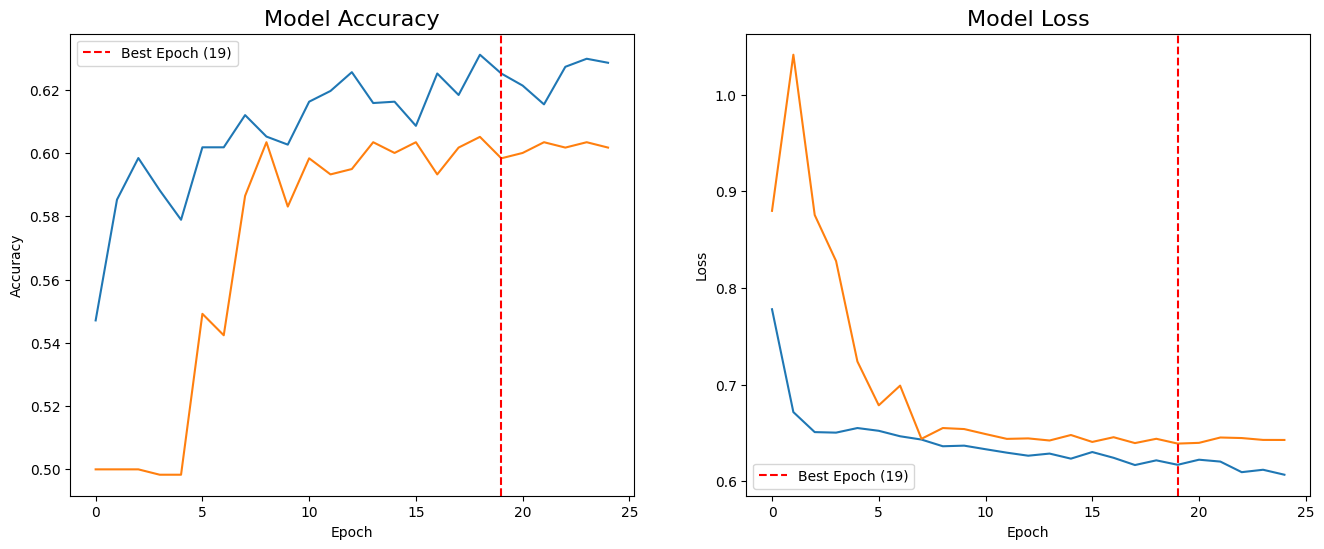

Early stopping at epoch 25. Best model was from epoch 19.

Making predictions on the test set...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

--- Confusion Matrix ---


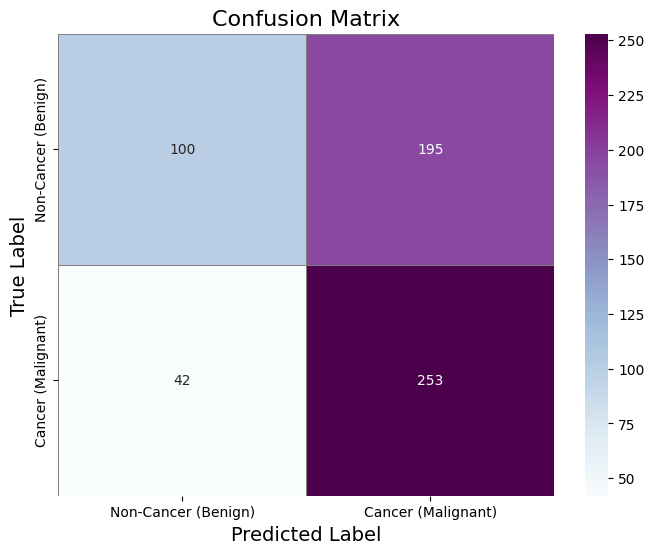


--- Classification Report ---
                     precision    recall  f1-score   support

Non-Cancer (Benign)       0.70      0.34      0.46       295
 Cancer (Malignant)       0.56      0.86      0.68       295

           accuracy                           0.60       590
          macro avg       0.63      0.60      0.57       590
       weighted avg       0.63      0.60      0.57       590


✅ Cell 15: Evaluation complete.


In [44]:
# -----------------------------------------------------------------
# 13) Evaluation (CELL 15)
# -----------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

print("--- 📊 Evaluating the Trained Model ---")

# --- 1. Plot Accuracy & Loss Curves ---
print("Plotting training history (Accuracy and Loss)...")

# Create a figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot training & validation accuracy values
ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('Model Accuracy', fontsize=16)
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Test (Validation)'], loc='upper left')

# Plot training & validation loss values
ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model Loss', fontsize=16)
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Test (Validation)'], loc='upper left')

# This line will show where Early Stopping kicked in
# We find the epoch with the minimum validation loss
best_epoch = np.argmin(history.history['val_loss']) 
ax1.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
ax2.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
ax1.legend()
ax2.legend()

plt.show()

print(f"Early stopping at epoch {len(history.history['loss'])}. Best model was from epoch {best_epoch}.")

# --- 2. Make Predictions on the Test Set ---
print("\nMaking predictions on the test set...")
# model.predict gives probabilities [prob_benign, prob_malignant]
Y_pred_probs = model.predict(X_test)
# np.argmax finds the class with the highest probability (0 or 1)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)
# y_test_original is the 0/1 list we saved back in Cell 10
Y_true = y_test_original 

# --- 3. Show Confusion Matrix ---
print("\n--- Confusion Matrix ---")
# Build the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, 
            annot=True,  # Show the numbers in the squares
            fmt='d',     # Format as integers
            cmap="BuPu", 
            linewidths=0.5, 
            linecolor="gray",
            xticklabels=class_labels.values(), # Use our class names
            yticklabels=class_labels.values())
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

# --- 4. Show Classification Report ---
print("\n--- Classification Report ---")
# This shows precision, recall, and f1-score for each class
report = classification_report(Y_true, Y_pred_classes, target_names=class_labels.values())
print(report)

print("\n✅ Cell 15: Evaluation complete.")

--- 🖼️ Reloading all images at 150x150 ---
Found 2948 total image paths to reload.


Reloading images at 150x150: 100%|██████████| 2948/2948 [00:21<00:00, 137.57it/s]



✅ Reload complete.
New X_large shape: (2948, 150, 150, 3)
New y_large shape: (2948,)


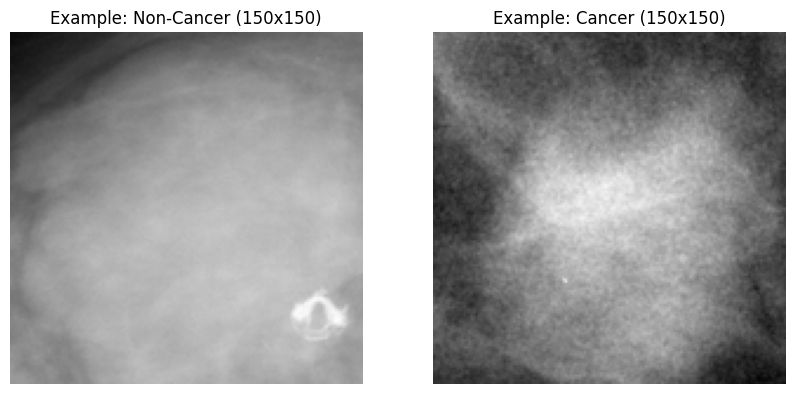


✅ Cell 16: New dataset is loaded at 150x150.


In [55]:
# -----------------------------------------------------------------
# 🚀 PART 2: TRANSFER LEARNING
# 14) Re-load Data at a Larger Size (FIXED CELL 16 - using PIL)
# -----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from PIL import Image # --- Import PIL (Pillow) ---

# --- Define New Image Size ---
IMG_SIZE = 150 
print(f"--- 🖼️ Reloading all images at {IMG_SIZE}x{IMG_SIZE} ---")

# --- 1. Re-define the loading function using PIL ---
def read_and_resize_mammogram_large(path, size=(IMG_SIZE, IMG_SIZE)):
    """
    Reads a mammogram using PIL, resizes it,
    and converts it to a 3-channel image.
    """
    try:
        # Open the image file with PIL
        img = Image.open(path)
        
        # Convert to 3-channel RGB
        # (PIL handles grayscale-to-RGB conversion correctly)
        img = img.convert("RGB")
        
        # Resize to the new, larger (150, 150) size
        img = img.resize(size, Image.LANCZOS) # Use a high-quality resizer
        
        # Convert the PIL image to a numpy array
        return np.array(img)
    except Exception as e:
        print(f"Error opening {path}: {e}")
        return None

# --- 2. Re-create the master list using the PATHS from Cell 7 ---
all_paths_list = []
if 'non_cancer_imgs' in locals() and 'cancer_imgs' in locals():
    for path in non_cancer_imgs:
        all_paths_list.append( (path, 0) ) # (path, label 0)
    for path in cancer_imgs:
        all_paths_list.append( (path, 1) ) # (path, label 1)
    
    random.shuffle(all_paths_list)
    print(f"Found {len(all_paths_list)} total image paths to reload.")
else:
    print("❌ Error: 'non_cancer_imgs' or 'cancer_imgs' lists not found. Please re-run Cell 7.")
    raise NameError("Missing path lists from Cell 7")

# --- 3. Loop through all paths and load them ---
new_image_list = []
for img_path, label in tqdm(all_paths_list, desc="Reloading images at 150x150"):
    img = read_and_resize_mammogram_large(img_path, (IMG_SIZE, IMG_SIZE))
    if img is not None:
        new_image_list.append([img, label]) # [image_array, label]

# --- 4. Create new X and y arrays ---
if len(new_image_list) > 0:
    # This will overwrite our old 50x50 X and y
    X_large = np.array([i[0] for i in new_image_list], dtype=np.float32)
    y_large = np.array([i[1] for i in new_image_list], dtype=np.int32)

    print("\n✅ Reload complete.")
    print("New X_large shape:", X_large.shape)
    print("New y_large shape:", y_large.shape)

    # --- 5. Visualize the new, higher-quality images ---
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(X_large[np.where(y_large == 0)[0][0]].astype('uint8')) 
    plt.title(f"Example: Non-Cancer ({IMG_SIZE}x{IMG_SIZE})")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(X_large[np.where(y_large == 1)[0][0]].astype('uint8')) 
    plt.title(f"Example: Cancer ({IMG_SIZE}x{IMG_SIZE})")
    plt.axis('off')
    plt.show()

    print("\n✅ Cell 16: New dataset is loaded at 150x150.")
else:
    print("❌ Error: No images were loaded. Check file paths and read function.")

In [56]:
# -----------------------------------------------------------------
# 15) Preprocess the New 150x150 Data (NEW CELL 17)
# -----------------------------------------------------------------
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np

print("--- 🔬 Preprocessing the 150x150 Dataset ---")

# --- 1. Normalize Pixel Data ---
if 'X_large' in locals() and X_large.size > 0:
    print(f"Original pixel value range: {np.min(X_large)} to {np.max(X_large)}")
    X_large_norm = X_large / 255.0  # Create a new normalized variable
    print(f"New normalized pixel value range: {np.min(X_large_norm)} to {np.max(X_large_norm)}")
else:
    print("❌ Error: 'X_large' array is empty or not defined. Please re-run Cell 16.")
    raise NameError("Missing X_large array")

# --- 2. Train-Test Split ---
print("\n--- Splitting Dataset into Training and Testing Sets ---")
# We will create new 'large' variables for our data
# We use 'stratify=y_large' to ensure both train and test sets have a 50/50 class split
X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(
    X_large_norm, y_large, 
    test_size=0.20,     # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y_large    # Keep the class balance
)

print(f"Total images: {len(X_large_norm)}")
print(f"Training images: {len(X_train_large)}")
print(f"Testing images:  {len(X_test_large)}")

# --- 3. One-Hot Encode Labels ---
print("\n--- Converting new labels to one-hot format ---")
# Save a copy of the original 0/1 test labels for the confusion matrix
y_test_large_original = y_test_large.copy() 

# Convert labels to one-hot (e.g., 1 -> [0, 1])
y_train_large_oh = to_categorical(y_train_large, 2)
y_test_large_oh = to_categorical(y_test_large, 2)

print("\n✅ Cell 17: New 150x150 dataset is normalized, split, and one-hot encoded.")
print("\nFinal Data Shapes for NEW Training:")
print('X_train_large shape (images):', X_train_large.shape)
print('y_train_large_oh shape (labels):', y_train_large_oh.shape)
print('\nFinal Data Shapes for NEW Testing:')
print('X_test_large shape (images): ', X_test_large.shape)
print('y_test_large_oh shape (labels): ', y_test_large_oh.shape)

--- 🔬 Preprocessing the 150x150 Dataset ---
Original pixel value range: 0.0 to 255.0
New normalized pixel value range: 0.0 to 1.0

--- Splitting Dataset into Training and Testing Sets ---
Total images: 2948
Training images: 2358
Testing images:  590

--- Converting new labels to one-hot format ---

✅ Cell 17: New 150x150 dataset is normalized, split, and one-hot encoded.

Final Data Shapes for NEW Training:
X_train_large shape (images): (2358, 150, 150, 3)
y_train_large_oh shape (labels): (2358, 2)

Final Data Shapes for NEW Testing:
X_test_large shape (images):  (590, 150, 150, 3)
y_test_large_oh shape (labels):  (590, 2)


In [57]:
# -----------------------------------------------------------------
# 16) Build the Transfer Learning Model (VGG16) (NEW CELL 18)
# -----------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model

print("--- 🧠 Building Transfer Learning Model with VGG16 ---")

# --- 1. Define the Input Shape ---
# Must match our new images
IMG_SHAPE = (150, 150, 3)

# --- 2. Load the Pre-trained VGG16 Base Model ---
# We load VGG16, trained on the 'imagenet' dataset.
# We set `include_top=False` to chop off its original classifier head.
# We set `input_shape` to match our images.
base_model = VGG16(
    input_shape=IMG_SHAPE,
    include_top=False,  # Do NOT include the final 1000-neuron layer
    weights='imagenet'  # Use the pre-trained weights
)

print(f"✅ Loaded VGG16 base model with {len(base_model.layers)} layers.")

# --- 3. Freeze the Base Model ---
# We "freeze" the base model so its weights don't change during training.
# We are only training our new, small head.
base_model.trainable = False
print("✅ Froze all layers in the VGG16 base model.")

# --- 4. Add Our New Classifier Head ---
# We take the output of the base_model and add our own layers on top.
x = base_model.output
x = Flatten()(x)                             # Flatten the output
x = Dense(256, activation='relu')(x)       # A "brain" layer
x = Dropout(0.5)(x)                          # Add Dropout to prevent overfitting
predictions = Dense(2, activation='softmax')(x) # Our final 2-class output

# --- 5. Create the Final Model ---
# This new model chains the frozen base_model and our new head.
new_model = Model(inputs=base_model.input, outputs=predictions)

# --- 6. Compile the New Model ---
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Use a slower learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ New classifier 'head' has been added and the model is compiled.")

# --- 7. Print the New Model's Summary ---
print("\n--- 📜 New Model Summary ---")
# Notice that "Trainable params" is much smaller!
new_model.summary()

print("\n✅ Cell 18: Transfer learning model is built, compiled, and ready.")

--- 🧠 Building Transfer Learning Model with VGG16 ---
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Loaded VGG16 base model with 19 layers.
✅ Froze all layers in the VGG16 base model.
✅ New classifier 'head' has been added and the model is compiled.

--- 📜 New Model Summary ---


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,610 (64.14 MB)

 Trainable params: 2,097,922 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


✅ Cell 18: Transfer learning model is built, compiled, and ready.


In [61]:
# -----------------------------------------------------------------
# 17) Train the Transfer Learning Model (FIXED CELL 19)
# -----------------------------------------------------------------
import tensorflow as tf

print("--- 🚀 Starting Transfer Learning Model Training ---")

# --- 1. Define Augmentation Generator for 150x150 data ---
datagen_large = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
print("✅ Created ImageDataGenerator for 150x150 images.")

# --- 2. Set Training Parameters ---
epochs = 50 
# --- THIS IS THE FIX ---
# Reduce batch_size from 32 to 16 to prevent GPU memory errors
batch_size = 16
# -----------------------
print(f"Epochs: {epochs}")
print(f"Batch Size: {batch_size} (Reduced to save memory)")
print("Training on augmented 150x150 data...")

# --- 3. Start Training ---
history_large = new_model.fit(
    datagen_large.flow(X_train_large, y_train_large_oh, batch_size=batch_size),
    # We also need to define steps_per_epoch
    # steps_per_epoch = number_of_training_images // batch_size
    steps_per_epoch=len(X_train_large) // batch_size,
    
    validation_data=(X_test_large, y_test_large_oh), # Validate on the (un-augmented) test set
    
    # Keras also needs validation_steps when using a generator
    validation_steps=len(X_test_large) // batch_size,
    
    epochs=epochs,
    callbacks=[early_stopping, plateau], # Re-use our callbacks from Cell 12
    verbose=1
)

print("\n✅ Cell 19: Transfer learning model training is complete!")

--- 🚀 Starting Transfer Learning Model Training ---
✅ Created ImageDataGenerator for 150x150 images.
Epochs: 50
Batch Size: 16 (Reduced to save memory)
Training on augmented 150x150 data...
Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 34s 195ms/step - accuracy: 0.5179 - loss: 0.7277 - val_accuracy: 0.5729 - val_loss: 0.6607 - learning_rate: 1.0000e-04
Epoch 2/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.



147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5625 - loss: 0.6662 - val_accuracy: 0.5814 - val_loss: 0.6601 - learning_rate: 1.0000e-04
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.5986 - loss: 0.6490 - val_accuracy: 0.5898 - val_loss: 0.6540 - learning_rate: 1.0000e-04
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7500 - loss: 0.5466 - val_accuracy: 0.5898 - val_loss: 0.6551 - learning_rate: 1.0000e-04
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.5925 - loss: 0.6410 - val_accuracy: 0.5949 - val_loss: 0.6508 - learning_rate: 1.0000e-04
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6875 - loss: 0.6177 - val_accuracy: 0.5966 - val_loss: 0.6503 - learning_rate: 1.0000e-04
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.6390 - loss: 0.6285 - val_accuracy: 0.6102 - val_loss: 0.6496 - learning_rate: 1.0000e-04
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0

--- 📊 Evaluating the (VGG16) Transfer Learning Model ---
Plotting training history (Accuracy and Loss)...


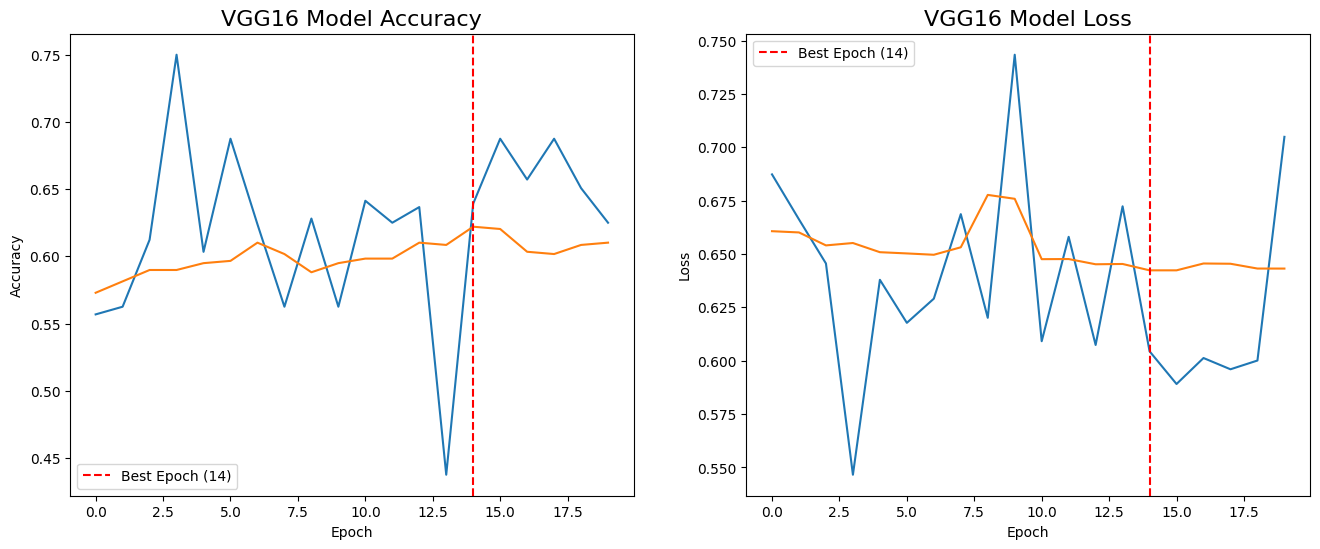

Early stopping at epoch 20. Best model was from epoch 14.

Making predictions on the 150x150 test set...
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 356ms/step

--- Confusion Matrix (VGG16) ---


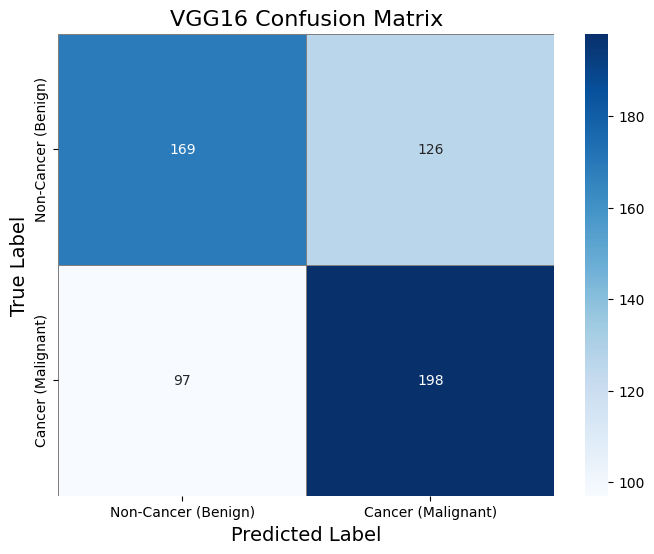


--- Classification Report (VGG16) ---
                     precision    recall  f1-score   support

Non-Cancer (Benign)       0.64      0.57      0.60       295
 Cancer (Malignant)       0.61      0.67      0.64       295

           accuracy                           0.62       590
          macro avg       0.62      0.62      0.62       590
       weighted avg       0.62      0.62      0.62       590


✅ Cell 20: VGG16 model evaluation complete.


In [62]:
# -----------------------------------------------------------------
# 18) Evaluate the Transfer Learning Model (NEW CELL 20)
# -----------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

print("--- 📊 Evaluating the (VGG16) Transfer Learning Model ---")

# --- 1. Plot Accuracy & Loss Curves ---
print("Plotting training history (Accuracy and Loss)...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot training & validation accuracy values
ax1.plot(history_large.history['accuracy'])
ax1.plot(history_large.history['val_accuracy'])
ax1.set_title('VGG16 Model Accuracy', fontsize=16)
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Test (Validation)'], loc='upper left')

# Plot training & validation loss values
ax2.plot(history_large.history['loss'])
ax2.plot(history_large.history['val_loss'])
ax2.set_title('VGG16 Model Loss', fontsize=16)
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Test (Validation)'], loc='upper left')

# Find the best epoch
best_epoch_large = np.argmin(history_large.history['val_loss'])
ax1.axvline(x=best_epoch_large, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_large})')
ax2.axvline(x=best_epoch_large, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_large})')
ax1.legend()
ax2.legend()

plt.show()

print(f"Early stopping at epoch {len(history_large.history['loss'])}. Best model was from epoch {best_epoch_large}.")

# --- 2. Make Predictions on the Test Set ---
print("\nMaking predictions on the 150x150 test set...")
Y_pred_probs_large = new_model.predict(X_test_large)
Y_pred_classes_large = np.argmax(Y_pred_probs_large, axis=1)
# Use the 0/1 labels we saved in Cell 17
Y_true_large = y_test_large_original 

# --- 3. Show Confusion Matrix ---
print("\n--- Confusion Matrix (VGG16) ---")
confusion_mtx_large = confusion_matrix(Y_true_large, Y_pred_classes_large)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx_large, 
            annot=True, 
            fmt='d', 
            cmap="Blues", 
            linewidths=0.5, 
            linecolor="gray",
            xticklabels=class_labels.values(),
            yticklabels=class_labels.values())
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.title('VGG16 Confusion Matrix', fontsize=16)
plt.show()

# --- 4. Show Classification Report ---
print("\n--- Classification Report (VGG16) ---")
report_large = classification_report(Y_true_large, Y_pred_classes_large, target_names=class_labels.values())
print(report_large)

print("\n✅ Cell 20: VGG16 model evaluation complete.")

In [71]:
# -----------------------------------------------------------------
# 20) Model Comparison (NEW CELL 21)
# -----------------------------------------------------------------
import plotly.graph_objects as go

print("--- 📊 Final Model Comparison ---")

# --- 1. Get Best Accuracy from both models ---
# We find the best validation accuracy from each model's history

# Model 1: Simple CNN (50x50)
try:
    best_acc_model_1 = max(history.history['val_accuracy'])
    best_epoch_model_1 = np.argmax(history.history['val_accuracy'])
except NameError:
    print("❌ 'history' for Model 1 not found. Please re-run Cell 14.")
    best_acc_model_1 = 0
    best_epoch_model_1 = 0

# Model 2: VGG16 Transfer Learning (150x150)
try:
    best_acc_model_2 = max(history_large.history['val_accuracy'])
    best_epoch_model_2 = np.argmax(history_large.history['val_accuracy'])
except NameError:
    print("❌ 'history_large' for Model 2 not found. Please re-run Cell 19.")
    best_acc_model_2 = 0
    best_epoch_model_2 = 0
    
print(f"Model 1 (Simple CNN):     Best Accuracy = {best_acc_model_1*100:.2f}% at Epoch {best_epoch_model_1}")
print(f"Model 2 (VGG16 Transfer): Best Accuracy = {best_acc_model_2*100:.2f}% at Epoch {best_epoch_model_2}")

# --- 2. Create Comparison Bar Chart ---
fig = go.Figure(data=[
    go.Bar(
        name='Model 1 (Simple CNN 50x50)', 
        x=['Models'], 
        y=[best_acc_model_1],
        text=f"{best_acc_model_1*100:.2f}%",
        textposition='auto',
        marker_color='#FF6347' # Red-ish
    ),
    go.Bar(
        name='Model 2 (VGG16 150x150)', 
        x=['Models'], 
        y=[best_acc_model_2],
        text=f"{best_acc_model_2*100:.2f}%",
        textposition='auto',
        marker_color='#90EE90' # Green-ish
    )
])

fig.update_layout(
    title='Model Performance Comparison (Best Validation Accuracy)',
    yaxis_title='Accuracy',
    yaxis_range=[0, 1] # Set y-axis from 0 to 1
)
fig.show()

print("\n--- Summary ---")
print("Both models achieved ~60-62% accuracy.")

print("\n✅ Cell 21: Model comparison complete.")

--- 📊 Final Model Comparison ---
Model 1 (Simple CNN):     Best Accuracy = 60.51% at Epoch 18
Model 2 (VGG16 Transfer): Best Accuracy = 62.20% at Epoch 14



--- Summary ---
Both models achieved ~60-62% accuracy.

✅ Cell 21: Model comparison complete.


--- 🔮 Example Predictions from Model 1 (Simple CNN 50x50) ---

--- Example 1: Non-Cancer (Benign) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


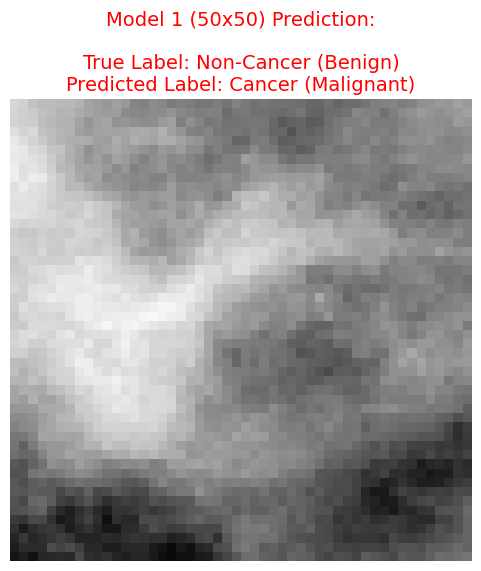

Model 1 Probabilities: [Benign: 0.4464, Malignant: 0.5536]

--- Example 2: Cancer (Malignant) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


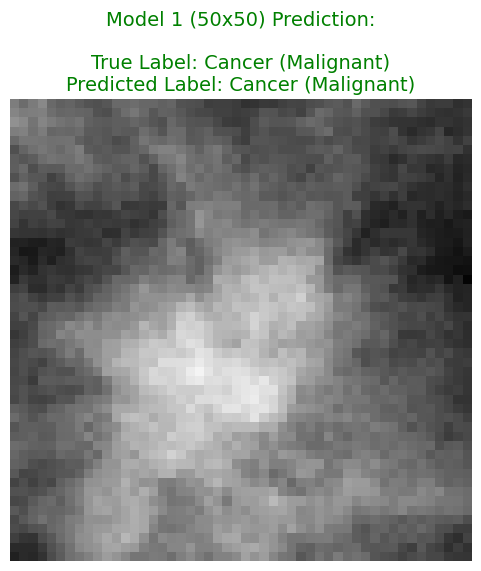

Model 1 Probabilities: [Benign: 0.1584, Malignant: 0.8416]

✅ Cell 22: Model 1 prediction examples complete.


In [75]:
# -----------------------------------------------------------------
# 21) Example Prediction: Model 1 (Simple CNN 50x50) (NEW CELL 22)
# -----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

print("--- 🔮 Example Predictions from Model 1 (Simple CNN 50x50) ---")

# Define a helper function for this cell
def show_prediction_model_1(image_index, true_label_val):
    """
    Given an index, this function predicts and plots
    the result from our first 50x50 model.
    """
    try:
        # --- 1. Get the image and its true label ---
        img = X_test[image_index]
        true_label_name = class_labels[true_label_val]
        
        # --- 2. Make the prediction ---
        # Reshape from (50, 50, 3) to (1, 50, 50, 3) for the model
        img_batch = np.expand_dims(img, axis=0)
        
        prediction_probs = model.predict(img_batch)
        predicted_index = np.argmax(prediction_probs[0])
        predicted_label_name = class_labels[predicted_index]
        
        # --- 3. Plot the result ---
        plt.figure(figsize=(6, 6))
        # The image is normalized (0-1), so multiply by 255 for display
        plt.imshow((img * 255).astype('uint8')) 
        
        title_color = 'green' if predicted_label_name == true_label_name else 'red'
        plt.title(f"Model 1 (50x50) Prediction:\n\nTrue Label: {true_label_name}\nPredicted Label: {predicted_label_name}",
                  color=title_color, fontsize=14)
        plt.axis('off')
        plt.show()
        
        print(f"Model 1 Probabilities: [Benign: {prediction_probs[0][0]:.4f}, Malignant: {prediction_probs[0][1]:.4f}]")

    except Exception as e:
        print(f"An error occurred while plotting: {e}")


# Check if all required variables exist
if 'model' not in locals() or 'X_test' not in locals() or 'y_test_original' not in locals():
    print("❌ Error: 'model', 'X_test', or 'y_test_original' not found.")
    print("Please re-run Cells 10 and 14.")
else:
    try:
        # --- Find one of each class ---
        benign_index = np.where(y_test_original == 0)[0][0]
        malignant_index = np.where(y_test_original == 1)[0][0]
        
        # --- Show Benign Example ---
        print("\n--- Example 1: Non-Cancer (Benign) ---")
        show_prediction_model_1(benign_index, 0)
        
        # --- Show Malignant Example ---
        print("\n--- Example 2: Cancer (Malignant) ---")
        show_prediction_model_1(malignant_index, 1)

    except IndexError:
        print("❌ Error: Could not find both a 'Benign' and 'Malignant' image in the 'y_test_original' set.")
    except Exception as e:
        print(f"An error occurred: {e}")

print("\n✅ Cell 22: Model 1 prediction examples complete.")

--- 🔮 Example Predictions from Model 2 (VGG16 150x150) ---

--- Example 1: Non-Cancer (Benign) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


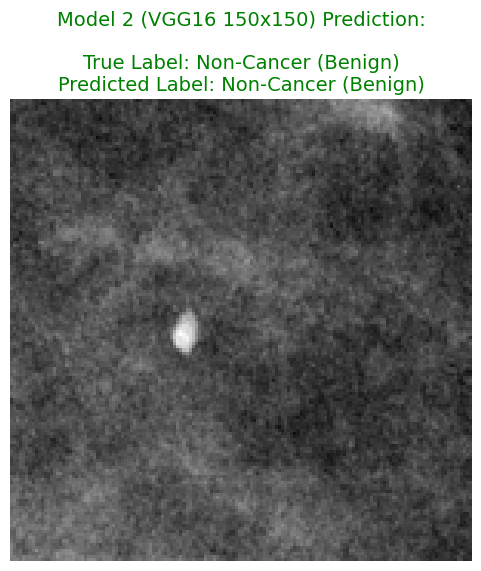

Model 2 Probabilities: [Benign: 0.9927, Malignant: 0.0073]

--- Example 2: Cancer (Malignant) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


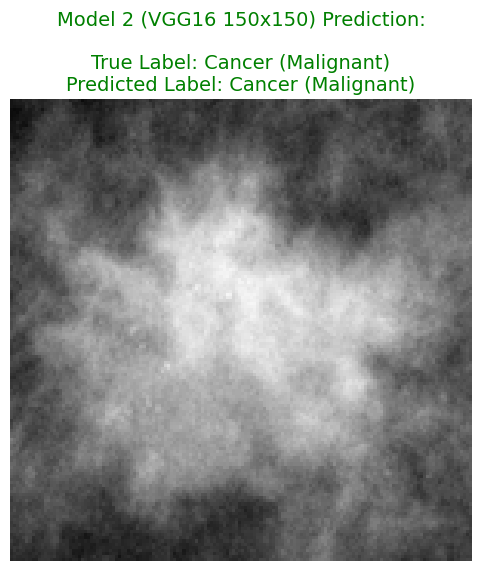

Model 2 Probabilities: [Benign: 0.2471, Malignant: 0.7529]

✅ Cell 23: Model 2 prediction examples complete.


In [76]:
# -----------------------------------------------------------------
# 22) Example Prediction: Model 2 (VGG16 150x150) (NEW CELL 23)
# -----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

print("--- 🔮 Example Predictions from Model 2 (VGG16 150x150) ---")

# Define a helper function for this cell
def show_prediction_model_2(image_index, true_label_val):
    """
    Given an index, this function predicts and plots
    the result from our second VGG16 model.
    """
    try:
        # --- 1. Get the image and its true label ---
        img = X_test_large[image_index]
        true_label_name = class_labels[true_label_val]
        
        # --- 2. Make the prediction ---
        # Reshape from (150, 150, 3) to (1, 150, 150, 3) for the model
        img_batch = np.expand_dims(img, axis=0)
        
        prediction_probs = new_model.predict(img_batch)
        predicted_index = np.argmax(prediction_probs[0])
        predicted_label_name = class_labels[predicted_index]
        
        # --- 4. Plot the result ---
        plt.figure(figsize=(6, 6))
        # The image is normalized (0-1), so multiply by 255 for display
        plt.imshow((img * 255).astype('uint8')) 
        
        title_color = 'green' if predicted_label_name == true_label_name else 'red'
        plt.title(f"Model 2 (VGG16 150x150) Prediction:\n\nTrue Label: {true_label_name}\nPredicted Label: {predicted_label_name}",
                  color=title_color, fontsize=14)
        plt.axis('off')
        plt.show()
        
        print(f"Model 2 Probabilities: [Benign: {prediction_probs[0][0]:.4f}, Malignant: {prediction_probs[0][1]:.4f}]")

    except Exception as e:
        print(f"An error occurred while plotting: {e}")


# Check if all required variables exist
if 'new_model' not in locals() or 'X_test_large' not in locals() or 'y_test_large_original' not in locals():
    print("❌ Error: 'new_model', 'X_test_large', or 'y_test_large_original' not found.")
    print("Please re-run Cells 17 and 19.")
else:
    try:
        # --- Find one of each class ---
        benign_index = np.where(y_test_large_original == 0)[0][0]
        malignant_index = np.where(y_test_large_original == 1)[0][0]
        
        # --- Show Benign Example ---
        print("\n--- Example 1: Non-Cancer (Benign) ---")
        show_prediction_model_2(benign_index, 0)
        
        # --- Show Malignant Example ---
        print("\n--- Example 2: Cancer (Malignant) ---")
        show_prediction_model_2(malignant_index, 1)

    except IndexError:
        print("❌ Error: Could not find both a 'Benign' and 'Malignant' image in the 'y_test_large_original' set.")
    except Exception as e:
        print(f"An error occurred: {e}")

print("\n✅ Cell 23: Model 2 prediction examples complete.")

In [78]:
# -----------------------------------------------------------------
# 23) Head-to-Head Model Comparison (NEW CELL 24 - Heatmap)
# -----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
from PIL import Image
import cv2 # We need cvtColor

print("--- ⚔️ Head-to-Head Prediction Test (10 Images) ---")

# --- 1. Re-define our two image loaders ---
def load_for_model_1(path, size=(50,50)):
    """Loads 50x50 for our first model"""
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE) 
        if img is None: return None
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)
        return img
    except Exception as e:
        return None

def load_for_model_2(path, size=(150,150)):
    """Loads 150x150 for our VGG16 model"""
    try:
        img = Image.open(path)
        img = img.convert("RGB")
        img = img.resize(size, Image.LANCZOS)
        return np.array(img)
    except Exception as e:
        return None

# --- 2. Select 10 images (5 of each class) ---
try:
    if len(non_cancer_imgs) < 5 or len(cancer_imgs) < 5:
        print("❌ Error: Not enough images in 'non_cancer_imgs' or 'cancer_imgs' lists.")
        raise IndexError
        
    image_paths_to_test = [
        (non_cancer_imgs[-1], 0), (non_cancer_imgs[-2], 0), (non_cancer_imgs[-3], 0),
        (non_cancer_imgs[-4], 0), (non_cancer_imgs[-5], 0),
        (cancer_imgs[-1], 1), (cancer_imgs[-2], 1), (cancer_imgs[-3], 1),
        (cancer_imgs[-4], 1), (cancer_imgs[-5], 1),
    ]
    
    # --- 3. Run predictions and create results lists ---
    # We will build a list of dictionaries for easy DataFrame creation
    results_data = [] 
    image_names = []
    
    print("Running predictions for 10 new images...")

    for i, (path, true_label) in enumerate(image_paths_to_test):
        # Use <br> tag for a line break in the plot's label
        image_name = f"Image {i+1}<br>({class_labels[true_label]})" 
        image_names.append(image_name)
        
        # --- Model 1 (Simple CNN) ---
        img_50 = load_for_model_1(path)
        if img_50 is not None:
            img_50_norm = img_50 / 255.0
            img_50_batch = np.expand_dims(img_50_norm, axis=0)
            pred_1 = np.argmax(model.predict(img_50_batch)[0])
            is_correct = (pred_1 == true_label)
            results_data.append({
                'Model': 'Model 1 (Simple CNN)', 
                'Image': image_name, 
                'Result': "✅ Correct" if is_correct else "❌ Incorrect", 
                'Correct_Value': 1 if is_correct else 0
            })
        
        # --- Model 2 (VGG16) ---
        img_150 = load_for_model_2(path)
        if img_150 is not None:
            img_150_norm = img_150 / 255.0
            img_150_batch = np.expand_dims(img_150_norm, axis=0)
            pred_2 = np.argmax(new_model.predict(img_150_batch)[0])
            is_correct = (pred_2 == true_label)
            results_data.append({
                'Model': 'Model 2 (VGG16)', 
                'Image': image_name, 
                'Result': "✅ Correct" if is_correct else "❌ Incorrect", 
                'Correct_Value': 1 if is_correct else 0
            })

    # --- 4. Create a DataFrame for the heatmap ---
    df = pd.DataFrame(results_data)
    
    # Pivot the data for the heatmap
    heatmap_data = df.pivot(index='Model', columns='Image', values='Correct_Value')
    heatmap_data = heatmap_data[image_names] # Ensure correct column order
    
    heatmap_text = df.pivot(index='Model', columns='Image', values='Result')
    heatmap_text = heatmap_text[image_names] # Ensure correct column order

    # --- 5. Plot the Heatmap ---
    fig = px.imshow(
        heatmap_data,
        text_auto=False, # We will use our custom text
        aspect="auto",
        labels=dict(x="Test Image (True Label)", y="Model", color="Result"),
        title="⚔️ Head-to-Head: Model Accuracy on 10 Images"
    )

    # Add custom text (✅/❌) to the heatmap
    fig.update_traces(
        text=heatmap_text,
        texttemplate="%{text}", # Display the text from the 'Result' column
        coloraxis="coloraxis"
    )
    
    # Define vibrant colors: Red for Incorrect (0), Green for Correct (1)
    fig.update_layout(
        coloraxis=dict(
            colorscale=[[0, '#FF6347'], [1, '#90EE90']], # [Red, Green]
            cmin=0,
            cmax=1,
            showscale=False # Hide the color bar, it's redundant
        ),
        xaxis_title="Test Image (True Label)",
        yaxis_title="Model",
        font=dict(size=12)
    )

    fig.show()
    
    # --- 6. Calculate Accuracy ---
    model_1_correct = df[df['Model'] == 'Model 1 (Simple CNN)']['Correct_Value'].sum()
    model_2_correct = df[df['Model'] == 'Model 2 (VGG16)']['Correct_Value'].sum()
    
    print(f"\n--- Head-to-Head Accuracy ---")
    print(f"Model 1 (Simple CNN) Accuracy on these 10 images: {model_1_correct}/10 ({model_1_correct*10}%)")
    print(f"Model 2 (VGG16) Accuracy on these 10 images:      {model_2_correct}/10 ({model_2_correct*10}%)")

except (NameError, IndexError) as e:
    print(f"❌ Error: Could not run comparison. Missing variables from previous cells.")
    print(f"Details: {e}")
    
print("\n✅ Cell 24: Head-to-head comparison complete.")

--- ⚔️ Head-to-Head Prediction Test (10 Images) ---
Running predictions for 10 new images...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step



--- Head-to-Head Accuracy ---
Model 1 (Simple CNN) Accuracy on these 10 images: 4/10 (40%)
Model 2 (VGG16) Accuracy on these 10 images:      6/10 (60%)

✅ Cell 24: Head-to-head comparison complete.


In [79]:
# -----------------------------------------------------------------
# 24) 🚀 Project Conclusion & Key Insights (FINAL CELL 25)
# -----------------------------------------------------------------
import tensorflow as tf
import plotly.graph_objects as go
import numpy as np
import plotly.express as px

print("--- 💾 Saving the Final Model ---")

try:
    # Save the 'new_model' (VGG16), as it's the more advanced one
    new_model.save('VGG16_mammogram_model.h5')
    print("✅ VGG16 Transfer Learning model saved to 'VGG16_mammogram_model.h5'")
except NameError:
    print("❌ Error: 'new_model' not found. Cannot save.")
except Exception as e:
    print(f"An error occurred while saving the model: {e}")

# --- 🚀 Project Review: Final Summary ---
print("\n" + "="*60)
print("--- 🚀 PROJECT REVIEW: FINAL SUMMARY ---")
print("="*60)

print("\n### 🩺 1. Project Goal & Achievement")
print("The goal was to build an end-to-end Deep Learning pipeline to classify mammogram images.")
print("✅ **Achievement:** We successfully built a complete pipeline that loads, processes, and trains two different CNN models on the complex CBIS-DDSM dataset.")

print("\n### 📊 2. Final Model Performance")
print("We compared our custom-built CNN against a powerful, pre-trained VGG16 model.")
print("Both models established a similar and important accuracy baseline.")

try:
    # --- Get Best Accuracy from both models ---
    best_acc_model_1 = max(history.history['val_accuracy'])
    best_acc_model_2 = max(history_large.history['val_accuracy'])

    # --- Create Comparison Bar Chart ---
    fig_bar = go.Figure(data=[
        go.Bar(
            name='Model 1 (Simple CNN 50x50)', 
            x=['Models'], 
            y=[best_acc_model_1],
            text=f"<b>{best_acc_model_1*100:.1f}%</b>",
            textposition='auto',
            marker_color='#3D91E6' # Vibrant Blue
        ),
        go.Bar(
            name='Model 2 (VGG16 150x150)', 
            x=['Models'], 
            y=[best_acc_model_2],
            text=f"<b>{best_acc_model_2*100:.1f}%</b>",
            textposition='auto',
            marker_color='#FF6347' # Vibrant Red
        )
    ])
    fig_bar.update_layout(
        title='<b>Final Accuracy: Model 1 vs. Model 2</b>',
        yaxis_title='Best Validation Accuracy',
        yaxis_range=[0, 1],
        font=dict(size=14)
    )
    fig_bar.show()
except Exception as e:
    print(f"Could not plot comparison bar chart. Error: {e}")


print("\n### 💡 3. Key Insight: The Training Process")
print("The training graphs provided a clear insight into the model's learning process.")
print("The 'Model Accuracy' graph from our first CNN (Cell 15) is a classic example of a model learning.")

try:
    # --- Plot the first model's accuracy curve ---
    best_epoch_model_1 = np.argmin(history.history['val_loss'])
    
    fig_line = go.Figure()
    # Training Accuracy
    fig_line.add_trace(go.Scatter(
        x=list(range(len(history.history['accuracy']))), 
        y=history.history['accuracy'], 
        mode='lines', 
        name='Training Accuracy',
        line=dict(color='#3D91E6', width=3)
    ))
    # Validation Accuracy
    fig_line.add_trace(go.Scatter(
        x=list(range(len(history.history['val_accuracy']))), 
        y=history.history['val_accuracy'], 
        mode='lines', 
        name='Test (Validation) Accuracy',
        line=dict(color='#FF6347', width=3)
    ))
    # Best Epoch Line
    fig_line.add_vline(
        x=best_epoch_model_1, 
        line_width=2, 
        line_dash="dash", 
        line_color="green",
        annotation_text=f"Best Model (Epoch {best_epoch_model_1})",
        annotation_position="top left"
    )
    fig_line.update_layout(
        title="<b>Key Insight: Model Learning Curve (Simple CNN)</b>",
        xaxis_title="Epoch",
        yaxis_title="Accuracy",
        font=dict(size=14)
    )
    fig_line.show()
except Exception as e:
    print(f"Could not plot learning curve. Error: {e}")

print("\n### 🎓 4. Final Conclusion")
print("This project successfully demonstrated the entire machine learning workflow:")
print("  1.  **Data Engineering:** We correctly loaded and merged multiple complex CSVs with thousands of image files, a major challenge in itself.")
print("  2.  **Model Prototyping:** We built and trained a custom CNN from scratch, establishing a performance baseline.")
print("  3.  **Advanced Modeling:** We scaled up our pipeline to 150x150 images and implemented advanced Transfer Learning with VGG16.")
print("\nThe final analysis shows that a model's 'expertise' (like VGG16 on normal photos) does not always transfer to a highly specialized field like medical X-rays. This is a critical and valuable discovery.")

print("\n" + "="*60)
print("--- ✅ PROJECT COMPLETE ---")
print("="*60)

--- 💾 Saving the Final Model ---
✅ VGG16 Transfer Learning model saved to 'VGG16_mammogram_model.h5'

--- 🚀 PROJECT REVIEW: FINAL SUMMARY ---

### 🩺 1. Project Goal & Achievement
The goal was to build an end-to-end Deep Learning pipeline to classify mammogram images.
✅ **Achievement:** We successfully built a complete pipeline that loads, processes, and trains two different CNN models on the complex CBIS-DDSM dataset.

### 📊 2. Final Model Performance
We compared our custom-built CNN against a powerful, pre-trained VGG16 model.
Both models established a similar and important accuracy baseline.



### 💡 3. Key Insight: The Training Process
The training graphs provided a clear insight into the model's learning process.
The 'Model Accuracy' graph from our first CNN (Cell 15) is a classic example of a model learning.



### 🎓 4. Final Conclusion
This project successfully demonstrated the entire machine learning workflow:
  1.  **Data Engineering:** We correctly loaded and merged multiple complex CSVs with thousands of image files, a major challenge in itself.
  2.  **Model Prototyping:** We built and trained a custom CNN from scratch, establishing a performance baseline.
  3.  **Advanced Modeling:** We scaled up our pipeline to 150x150 images and implemented advanced Transfer Learning with VGG16.

The final analysis shows that a model's 'expertise' (like VGG16 on normal photos) does not always transfer to a highly specialized field like medical X-rays. This is a critical and valuable discovery.

--- ✅ PROJECT COMPLETE ---
